In [1]:
import os
import gc
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tqdm import tqdm
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy("mixed_float16")

# 1. CONFIGURATION GPU & REPRODUCTIBILITÉ
os.environ.pop('CUDA_VISIBLE_DEVICES', None)  # Libère le GPU si bloqué

gpus = tf.config.list_physical_devices('GPU')
print(f"GPU détecté(s) : {len(gpus)}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("Mode GPU actif")
else:
    print("ATTENTION : aucun GPU détecté")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

GPU détecté(s) : 2
Mode GPU actif


In [2]:
# 2. HYPERPARAMÈTRES & CHEMINS

EMB_DIM = 128
BASE_FILTERS = 16
BATCH_SIZE = 32
EPOCHS = 300
LR = 3e-4

WAVE_DIR = '/kaggle/input/datasets/nadakamel3/echonext-waveforms-preprocessed'
TAB_DIR = '/kaggle/input/datasets/nadakamel3/echonext-tabular-features'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SPLITS = {
    'train': ('EchoNext_train_cleaned.npy', 'EchoNext_train_tabular_features.npy'),
    'val':   ('EchoNext_val_cleaned.npy',   'EchoNext_val_tabular_features.npy'),
    'test':  ('EchoNext_test_cleaned.npy',  'EchoNext_test_tabular_features.npy'),
}

Ce script réalise deux opérations majeures pour préparer les données avant l'entraînement d'un modèle multimodal (combinant signaux et données tabulaires) :

Le chargement synchronisé : Il charge en mémoire les signaux ECG (waves) et leurs métadonnées tabulaires associées (tabs) pour les trois ensembles (Train, Val, Test).

L'imputation robuste par la médiane : Il nettoie les valeurs manquantes (NaN) des données tabulaires en utilisant uniquement les statistiques du jeu d'entraînement pour éviter toute fuite de données (data leakage).

In [3]:
# 3. CHARGEMENT ET PRÉ-TRAITEMENT DES DONNÉES
def load_split(name):
    wfile, tfile = SPLITS[name]
    wpath = os.path.join(WAVE_DIR, wfile)
    tpath = os.path.join(TAB_DIR, tfile)
    
    waves = np.load(wpath).astype(np.float32)
    tabs  = np.load(tpath).astype(np.float32)

    # La ligne assert waves.shape[0] == tabs.shape[0] est une barrière de sécurité critique. Elle vérifie que le nombre de patients ($N$) est 
    # strictement identique entre la matrice de signaux et le tableau de caractéristiques afin d'éviter tout désalignement.
    assert waves.shape[0] == tabs.shape[0]
    print(f"[{name}] waves {waves.shape} + tabs {tabs.shape}")
    return waves, tabs

train_w, train_t = load_split('train')
val_w,   val_t   = load_split('val')
test_w,  test_t  = load_split('test')

# Enregistre le nombre exact de variables numériques (colonnes) présentes dans le tableau, ce qui servira à configurer la couche d'entrée du 
# réseau de neurones.
TAB_DIM = train_t.shape[1]

# La médiane de chaque colonne est calculée uniquement sur l'ensemble d'entraînement (train_t) avec np.nanmedian (qui ignore les NaN existants). 
# On n'utilise jamais le jeu de validation ou de test pour ce calcul afin de ne pas biaiser l'évaluation du modèle.
col_medians = np.nanmedian(train_t, axis=0)

def impute_median(data, medians):
    data = data.copy() # Effectue une copie locale pour éviter de modifier par accident les tableaux d'origine en mémoire.
    for i in range(data.shape[1]):
        mask = np.isnan(data[:, i])
        if mask.any(): # S'il y a des valeurs manquantes (mask.any()), elles sont remplacées par la médiane correspondante précalculée (medians[i]). Un message s'affiche pour indiquer le nombre exact de corrections effectuées.
            data[mask, i] = medians[i]
            print(f"  -> Colonne {i} : {mask.sum()} NaN imputés par médiane={medians[i]:.4f}")
    return data

print("\n--- Imputation des NaNs ---")
train_t = impute_median(train_t, col_medians)
val_t   = impute_median(val_t, col_medians)
test_t  = impute_median(test_t, col_medians)

# Contrôle qualité
# Une vérification ultime est lancée sur les trois jeux de données tabulaires après traitement. Si un seul NaN a échappé à l'imputation, 
# le script s'arrête immédiatement en levant une erreur. Si le message "Données validées : aucun NaN." s'affiche, la pipeline est prête pour l'entraînement.
assert not np.isnan(train_t).any() or np.isnan(val_t).any() or np.isnan(test_t).any(), "NaN résiduel trouvé !"
print("Données validées : aucun NaN.")

[train] waves (72475, 2500, 12) + tabs (72475, 7)
[val] waves (4626, 2500, 12) + tabs (4626, 7)
[test] waves (5442, 2500, 12) + tabs (5442, 7)

--- Imputation des NaNs ---
  -> Colonne 5 : 1 NaN imputés par médiane=-0.0878
Données validées : aucun NaN.


Ce bloc de code utilise l'API tf.data de TensorFlow pour construire un pipeline d'alimentation performant, optimisé pour l'entraînement d'un auto-encodeur multimodal. L'auto-encodeur reçoit deux types d'entrées (les signaux ECG w et les données tabulaires t) et apprend à reconstruire uniquement le signal ECG d'origine en sortie.

In [4]:
# 4. CRÉATION DES DATASETS TF.DATA

# L'Auto-encodeur prend (ECG, Tabulaire) en entrée et doit reconstruire l'ECG d'origine en sortie
train_ds = tf.data.Dataset.from_tensor_slices((train_w, train_t)) # Ce bloc de code utilise l'API tf.data de TensorFlow pour construire un pipeline d'alimentation performant, optimisé pour l'entraînement d'un auto-encodeur multimodal. L'auto-encodeur reçoit deux types d'entrées (les signaux ECG w et les données tabulaires t) et apprend à reconstruire uniquement le signal ECG d'origine en sortie.
train_ds = train_ds.shuffle(5000, reshuffle_each_iteration=True)
# 5000 (Taille du tampon) : TensorFlow remplit un tampon de 5000 exemples, pioche aléatoirement dedans pour créer les lots, puis le remet à jour. 
# Cela garantit un bon mélange indispensable à la convergence du modèle.
# reshuffle_each_iteration=True : Force un mélange totalement différent à chaque nouvelle époque d'entraînement.


# Regroupe les exemples individuels en paquets de taille BATCH_SIZE pour permettre le calcul parallèle sur GPU.
train_ds = train_ds.batch(BATCH_SIZE)

# C'est l'étape clé de l'auto-encodeur. La fonction de coût (Loss) compare la sortie du réseau à sa cible. 
# Le format standard attendu par Keras est (Entrées, Cibles).
#Entrées = (w, t) : Le modèle reçoit le couple multimodal (Signal ECG + Données tabulaires).
# Cibles = w : La cible à reconstruire est le signal ECG initial.
train_ds = train_ds.map(lambda w, t: ((w, t), w)) 

# Mécanisme de chevauchement (Overlap) : Pendant que la carte graphique (GPU) est en train d'exécuter l'étape d'entraînement sur le lot actuel, 
# le processeur (CPU) prépare et charge déjà en arrière-plan les lots suivants en mémoire RAM.
# tf.data.AUTOTUNE : Laisse TensorFlow gérer dynamiquement la taille idéale du tampon de pré-chargement pour maximiser l'utilisation des ressources 
# et éliminer les goulets d'étranglement.
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Le jeu de validation (val_ds) suit la même logique mais ne contient pas l'étape shuffle. Il est inutile (et mathématiquement déconseillé) de mélanger
# les données de validation, car l'évaluation doit simplement mesurer la perte de reconstruction de manière stable d'une époque à l'autre.
val_ds = tf.data.Dataset.from_tensor_slices((val_w, val_t))
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.map(lambda w, t: ((w, t), w))
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

I0000 00:00:1785798093.677440      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785798093.681998      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
# 5. ARCHITECTURE DU MODÈLE MULTIMODAL (ENCODEUR, DÉCODEUR & AUTO-ENCODEUR)


def res_block(x, filters, stride=1):
    """
    Bloc résiduel 1D (ResNet Block) appliqué au traitement du signal ECG.
    """
    shortcut = x
    # Si les dimensions spatiales ou le nombre de canaux changent, on adapte le raccourci
    if stride != 1 or int(x.shape[-1]) != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same', use_bias=False,\
                                  kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    # Première convolution
    x = layers.Conv1D(filters, 7, strides=stride, padding='same', use_bias=False,\
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    
    # Deuxième convolution
    x = layers.Conv1D(filters, 7, padding='same', use_bias=False,\
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    
    # Connexion résiduelle
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    x = layers.Dropout(0.2)(x)
    return x


# A. BRANCHE ENCODEUR MULTIMODAL

#  Entrée 1 : Signal ECG (Temporel) 
wave_in = keras.Input(shape=(2500, 12), name='ecg_input')

# Traitement initial du signal
x = layers.Conv1D(BASE_FILTERS, 15, strides=2, padding='same', use_bias=False,\
                  kernel_initializer='he_normal')(wave_in)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)
x = layers.MaxPooling1D(3, strides=2, padding='same')(x)

# Extraction de caractéristiques profondes par blocs résiduels
x = res_block(x, BASE_FILTERS, 1)
x = res_block(x, BASE_FILTERS, 1)
x = res_block(x, BASE_FILTERS*2, 2)
x = res_block(x, BASE_FILTERS*2, 1)
x = res_block(x, BASE_FILTERS*4, 2)
x = res_block(x, BASE_FILTERS*4, 1)
x = res_block(x, BASE_FILTERS*8, 2)
x = res_block(x, BASE_FILTERS*8, 1)

# Compression spatiale globale du signal ECG
ecg_feat = layers.GlobalAveragePooling1D()(x) 


#  Entrée 2 : Données Tabulaires (Cliniques) 
tab_in = keras.Input(shape=(TAB_DIM,), name='tabular_input')
t = layers.Dense(64, use_bias=False, kernel_initializer='he_normal')(tab_in)
t = layers.BatchNormalization()(t)
t = layers.ReLU()(t)
t = layers.Dropout(0.2)(t)


#  Fusion Multimodale et Espace Latent (Embedding) 
combined = layers.Concatenate()([ecg_feat, t])

e = layers.Dense(256, kernel_initializer='he_normal')(combined)
e = layers.BatchNormalization()(e)
e = layers.ReLU()(e)
e = layers.Dropout(0.3)(e)

# Couche dense linéaire pour l'embedding
e = layers.Dense(EMB_DIM, name='embedding_layer', kernel_initializer='he_normal')(e)

# Normalisation L2 compatible Keras 3
emb = tf.keras.layers.UnitNormalization(
    axis=1,
    name="embedding_output"
)(e)

# Instanciation de l'Encodeur Global
encoder = keras.Model(inputs=[wave_in, tab_in], outputs=emb, name='Encoder')


# B. BRANCHE DÉCODEUR (Reconstruction Précise de la dimension 2500)

dec_in = keras.Input(shape=(EMB_DIM,), name='decoder_input')

# 1. Projection de l'embedding vers un espace plat compatible (312 étapes * 64 filtres)
d = layers.Dense(312 * 64, kernel_initializer='he_normal')(dec_in)
d = layers.BatchNormalization()(d)
d = layers.ReLU()(d)

# Reconstruction de la structure 3D temporelle : forme initiale (312, 64)
d = layers.Reshape((312, 64))(d)

# 2. Échantillonnage ascendant (Upsampling) par Convolutions Transposées
# Étape 1 : (312, 64) -> (624, 32)
d = layers.Conv1DTranspose(filters=32, kernel_size=7, strides=2, padding='same', use_bias=False)(d)
d = layers.BatchNormalization()(d)
d = layers.ReLU()(d)

# Étape 2 : (624, 32) -> (1248, 16)
d = layers.Conv1DTranspose(filters=16, kernel_size=7, strides=2, padding='same', use_bias=False)(d)
d = layers.BatchNormalization()(d)
d = layers.ReLU()(d)

# Étape 3 : (1248, 16) -> (2496, 12)
d = layers.Conv1DTranspose(filters=12, kernel_size=7, strides=2, padding='same', use_bias=False)(d)
d = layers.BatchNormalization()(d)
d = layers.ReLU()(d)

# 3. Ajustement exact à 2500 : Ajout de 4 zéros répartis de manière égale (2 en début, 2 en fin)
# Forme obtenue : 2496 + 2 + 2 = 2500
d = layers.ZeroPadding1D(padding=(2, 2))(d)

# Couche de convolution finale pour projeter exactement sur les 12 canaux de l'ECG d'origine
decoded_wave = layers.Conv1D(12, 1, padding='same', name='decoded_output')(d)

# Instanciation du Décodeur Global
decoder = keras.Model(inputs=dec_in, outputs=decoded_wave, name='Decoder')


# C. LE MODÈLE AUTO-ENCODEUR COMPLET

# Connexion bout-en-bout : Les entrées passent par l'encodeur, puis le résultat est reconstruit par le décodeur
autoencoder_out = decoder(encoder([wave_in, tab_in]))
autoencoder = keras.Model(inputs=[wave_in, tab_in], outputs=autoencoder_out, name='Autoencoder')


# D. AFFICHAGE DES SUMMARIES

print("\n" + "="*50)
print("STRUCTURE DE L'ENCODEUR")
print("="*50)
encoder.summary()

print("\n" + "="*50)
print("STRUCTURE DU DÉCODEUR")
print("="*50)
decoder.summary()

print("\n" + "="*50)
print("STRUCTURE DE L'AUTO-ENCODEUR COMPLET")
print("="*50)
autoencoder.summary()


STRUCTURE DE L'ENCODEUR


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 2500, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1250, 16)  │      2,880 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1250, 16)  │         64 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 1250, 16)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 625, 16)   │          0 │ re_lu[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 625, 16)   │      1,792 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 16)   │         64 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 625, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 625, 16)   │      1,792 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 16)   │         64 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 625, 16)   │          0 │ batch_normalizat… │
│                     │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 625, 16)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 625, 16)   │          0 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 625, 16)   │      1,792 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 16)   │         64 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 625, 16)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 625, 16)   │      1,792 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 625, 16)   │         64 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 625, 16)   │          0 │ batch_normalizat… │
│                     │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 625, 16)   │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 636,480 (2.43 MB)

 Trainable params: 633,440 (2.42 MB)

...

Model: "Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 2500, 12)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tabular_input       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 128)       │    636,480 │ ecg_input[0][0],  │
│ (Functional)        │                   │            │ tabular_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Decoder             │ (None, 2500, 12)  │  2,675,404 │ Encoder[0][0]     │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,311,884 (12.63 MB)

 Trainable params: 3,268,788 (12.47 MB)

 Non-trainable params: 43,096 (168.34 KB)

In [6]:
# 6. COMPILATION ET CALLBACKS 
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss='mse',      # Mean Squared Error adapté à la reconstruction de signaux
    metrics=['mae']  # Mean Absolute Error pour suivre la progression clinique
)

# Liste des Callbacks mis à jour
callbacks = [
    # Sauvegarde le meilleur modèle selon la perte de validation
    ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, 'best_autoencoder.keras'),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    # Arrête l'entraînement si le modèle n'évolue plus pendant 5 époques
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    # SOLUTION AU "LR BLOQUÉ" : Divise le LR par 2 si la val_loss ne diminue pas pendant 2 époques
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=15,
        min_lr=1e-6,
        verbose=1
    )
]

In [7]:
# 7. ENTRAÎNEMENT
print("\nDébut de l'entraînement...")
history = autoencoder.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1 
)


Début de l'entraînement...
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/tensorflow/python/util/numpy_compat.py:47: RuntimeWarning: overflow encountered in cast
  return np.array(values, copy=copy, order=order).astype(dtype)


   8/2265 ━━━━━━━━━━━━━━━━━━━━ 37s 16ms/step - loss: 1.4663 - mae: 0.7997

I0000 00:00:1785798163.776650      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2265/2265 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.0237 - mae: 0.5650
Epoch 1: val_loss improved from None to 0.96978, saving model to /kaggle/working/best_autoencoder.keras

Epoch 1: finished saving model to /kaggle/working/best_autoencoder.keras
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 104s 25ms/step - loss: 0.9827 - mae: 0.5398 - val_loss: 0.9698 - val_mae: 0.5290 - learning_rate: 3.0000e-04
Epoch 2/300
2262/2265 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9688 - mae: 0.5305
Epoch 2: val_loss improved from 0.96978 to 0.96963, saving model to /kaggle/working/best_autoencoder.keras

Epoch 2: finished saving model to /kaggle/working/best_autoencoder.keras
2265/2265 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - loss: 0.9689 - mae: 0.5306 - val_loss: 0.9696 - val_mae: 0.5288 - learning_rate: 3.0000e-04
Epoch 3/300
2264/2265 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.9686 - mae: 0.5307
Epoch 3: val_loss improved from 0.96963 to 0.96564, saving model to /kaggle/working/best_autoencoder.keras

Epoch 3: fi

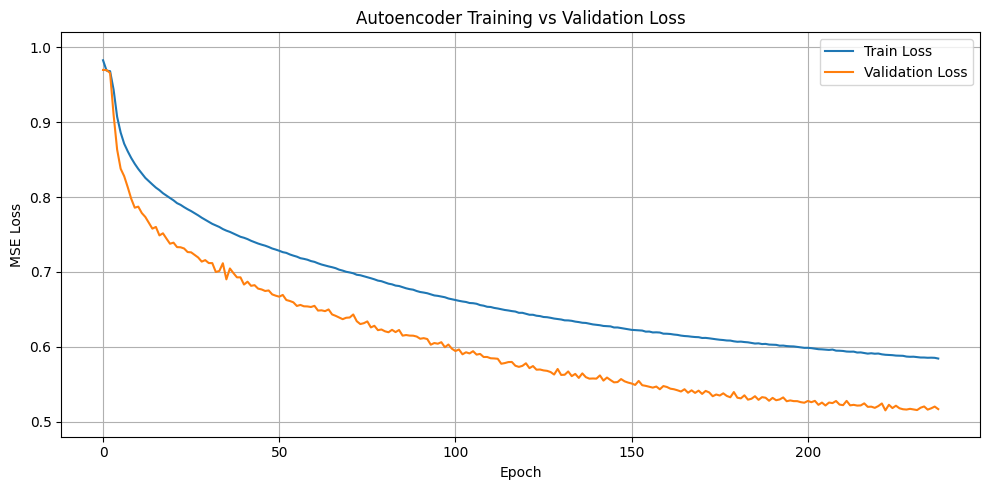

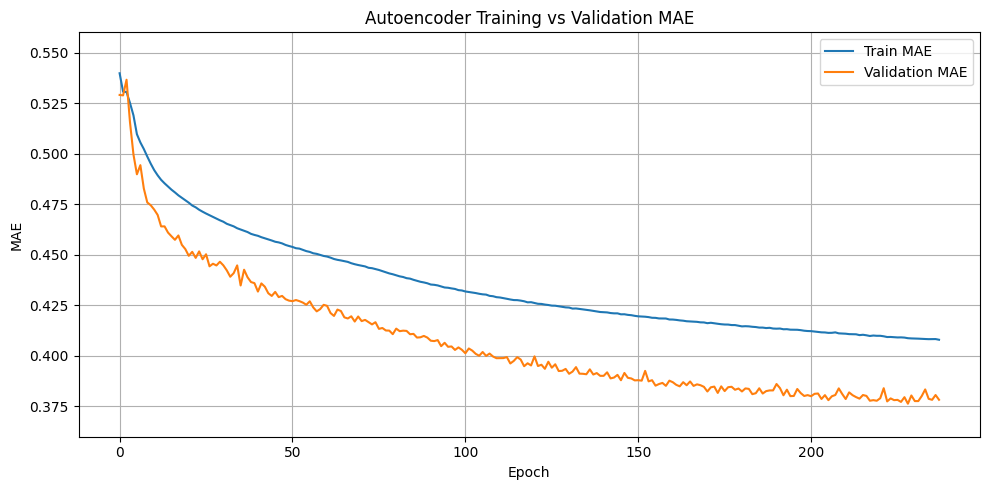

In [8]:
import matplotlib.pyplot as plt

# Loss (MSE) 
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training vs Validation Loss')
plt.ylim(0.48, 1.02)   
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# MAE 
plt.figure(figsize=(10, 5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Autoencoder Training vs Validation MAE')
plt.ylim(0.36, 0.56) 
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# 8. EXTRACTION ET SAUVEGARDE DES EMBEDDINGS PAR CHUNKS 
import gc
import os
import numpy as np

def extract_and_save_by_chunks(waves, tabs, name, chunk_size=5000):
    print(f"\n{"="*60}")
    print(f"EXTRACTION SÉCURISÉE DES EMBEDDINGS [{name.upper()}] (Total: {len(waves)})")
    print(f"{"="*60}")
    
    output_file = os.path.join(OUTPUT_DIR, f'embeddings_{name}.npy')
    
    # Si le fichier existe déjà d'une session précédente, on le supprime pour repartir à zéro
    if os.path.exists(output_file):
        os.remove(output_file)
        
    num_patients = len(waves)
    
    # Découpage et traitement par Chunks
    for i in range(0, num_patients, chunk_size):
        start_idx = i
        end_idx = min(i + chunk_size, num_patients)
        print(f"\n-> Traitement du Chunk : Patients {start_idx} à {end_idx}...")
        
        # 1. Sélection du chunk en RAM
        wave_chunk = waves[start_idx:end_idx]
        tab_chunk = tabs[start_idx:end_idx]
        
        # 2. Inférence ultra-rapide sur le petit chunk
        chunk_embeddings = encoder.predict([wave_chunk, tab_chunk], batch_size=256, verbose=1)
        
        # 3. Sauvegarde ou Accumulation physique sur le disque dur (.npy)
        if not os.path.exists(output_file):
            # Premier passage : on crée le fichier
            np.save(output_file, chunk_embeddings)
        else:
            # Passages suivants : on charge, on ajoute (concatenate) et on ré-enregistre
            existing_embeddings = np.load(output_file)
            updated_embeddings = np.concatenate([existing_embeddings, chunk_embeddings], axis=0)
            np.save(output_file, updated_embeddings)
            
            # Libération immédiate de la variable temporaire de rechargement
            del existing_embeddings, updated_embeddings
            
        # 4. Nettoyage agressif de la RAM à chaque fin de chunk
        del wave_chunk, tab_chunk, chunk_embeddings
        gc.collect()
        
    # Vérification finale du fichier écrit sur le disque
    final_check = np.load(output_file)
    print(f"\n[SUCCÈS] Fichier enregistré : {output_file}")
    print(f"-> Dimension finale validée sur le disque : {final_check.shape}")
    del final_check
    gc.collect()

#  EXÉCUTION DE LA STRATÉGIE PAR MORCEAUX 

# 1. Extraction du Train (Le plus gros bloc, traité par paquets de 5000)
extract_and_save_by_chunks(train_w, train_t, 'train', chunk_size=5000)

# 2. Extraction de la Validation (Plus petit, peut être fait d'un coup ou en 1 chunk)
extract_and_save_by_chunks(val_w, val_t, 'val', chunk_size=5000)

# 3. Extraction du Test
extract_and_save_by_chunks(test_w, test_t, 'test', chunk_size=5000)

print("\n  Tous les embeddings sont sauvegardés par blocs sans aucun risque de crash RAM.")


EXTRACTION SÉCURISÉE DES EMBEDDINGS [TRAIN] (Total: 72475)

-> Traitement du Chunk : Patients 0 à 5000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 192ms/step

-> Traitement du Chunk : Patients 5000 à 10000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

-> Traitement du Chunk : Patients 10000 à 15000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

-> Traitement du Chunk : Patients 15000 à 20000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

-> Traitement du Chunk : Patients 20000 à 25000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

-> Traitement du Chunk : Patients 25000 à 30000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

-> Traitement du Chunk : Patients 30000 à 35000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

-> Traitement du Chunk : Patients 35000 à 40000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

-> Traitement du Chunk : Patients 40000 à 45000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

-> Traitement du Chunk : Patients 45000 à 50000...
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

-> Traitement du Chunk :